# Basic Pareto Sweep — the Full Exploration Space

**Question:** where does the (throughput/GPU, interactivity) Pareto frontier come from? What does the underlying point cloud look like — i.e. what's the full space of `(PP, TP, EP, SP, B)` choices that the frontier selects from?

The other Pareto notebooks (`pareto_vs_io`, `pareto_vs_mem`, `pareto_vs_overhead`) only plot the frontier — the upper-right envelope of this cloud. This notebook shows the cloud itself so the frontier-extraction step is visible.

**Setup:** GPT-1.8T MoE @ FP4 on GB200 NVL72 (baseline hardware, no I/O / HBM / overhead sweeps). Enumerate every valid `(PP, TP, EP, SP)` partition, sweep batch `B` from 1 up to the KV-paging max, score each `(partition, B)` evaluation, then extract the upper-right envelope.

**What's on the plot:**

- **Gray cloud** — every valid `(partition, B)` evaluation in the exploration space.
- **Colored points** — the same cloud, but colored by partition PP (so you can see which shape dominates which region).
- **Bold line + markers** — the extracted Pareto frontier (upper-right envelope).
- **Annotations** — winning `(PP, TP, EP, B)` at a few frontier corners.

The ratio `|frontier| / |cloud|` quantifies how much of the search space is actually useful — most `(partition, B)` evaluations are dominated.

## 1. Imports and spec loading

In [1]:
from __future__ import annotations

import math
from copy import deepcopy
from dataclasses import dataclass

import matplotlib.pyplot as plt

from llm_perf import InferenceCalculator
from llm_perf.core.kv_paging_model import KVPagingConfig, compute_kv_paging
from llm_perf.core.memory_model import compute_memory
from llm_perf.io import load_model_spec, load_system_spec, load_tuning_spec
from llm_perf.specs.partition_spec import PartitionSpec

MODEL = "llm_perf/database/model/gpt_1_8t_moe.json"
SYSTEM = "llm_perf/database/system/gb200.72gpu.json"
TUNER = "llm_perf/database/tuner/gpt_1_8t_moe.tuner.json"

S_DECODE = 8192
BPP_FP4 = 0.5

model = load_model_spec(MODEL)
model.bytes_per_param = BPP_FP4
system = load_system_spec(SYSTEM)
tuner_base = load_tuning_spec(TUNER)
tuner_base.S_decode = S_DECODE
tuner_base.B_decode = 1

print(f"Model: {model.name}  L={model.L}  H={model.H}  n_kv={model.n_kv}  b={model.bytes_per_param}")
print(f"System: {system.num_devices} GPUs  HBM={system.device.hbm_bandwidth_GBps:.0f} GB/s  "
      f"peak={system.device.peak_flops_TF:.0f} TF  "
      f"scale-up={system.network_domains['TP'].bandwidth_GBps:.0f} GB/s · "
      f"{system.network_domains['TP'].alpha_us:.2f} μs")

Model: GPT-1.8T-MoE  L=120  H=20480  n_kv=16  b=0.5
System: 72 GPUs  HBM=8000 GB/s  peak=9000 TF  scale-up=900 GB/s · 0.50 μs


## 2. Partition enumeration

GPT-1.8T MoE divisibility constraints: `PP | L=120`, `TP | n_kv=16` and `H=20480`, `EP | n_experts=16`. `SP=1` (ring attention unused here). We drop partitions that exceed the 72 available GPUs.

In [2]:
PP_CHOICES = [1, 2, 3, 4, 6, 8]
TP_CHOICES = [1, 2, 4, 8, 16]
EP_CHOICES = [1, 2, 4, 8, 16]
SP_CHOICES = [1]


def enumerate_partitions(num_devices: int) -> list[PartitionSpec]:
    out: list[PartitionSpec] = []
    for pp in PP_CHOICES:
        for tp in TP_CHOICES:
            for ep in EP_CHOICES:
                for sp in SP_CHOICES:
                    if pp * tp * ep * sp > num_devices:
                        continue
                    out.append(PartitionSpec(PP=pp, TP=tp, EP=ep, SP=sp))
    return out


partitions = enumerate_partitions(system.num_devices)
print(f"Valid partitions: {len(partitions)}")
print("First 10:", [f"PP={p.PP} TP={p.TP} EP={p.EP}" for p in partitions[:10]])

Valid partitions: 91
First 10: ['PP=1 TP=1 EP=1', 'PP=1 TP=1 EP=2', 'PP=1 TP=1 EP=4', 'PP=1 TP=1 EP=8', 'PP=1 TP=1 EP=16', 'PP=1 TP=2 EP=1', 'PP=1 TP=2 EP=2', 'PP=1 TP=2 EP=4', 'PP=1 TP=2 EP=8', 'PP=1 TP=2 EP=16']


## 3. Sweep every `(partition, B)` in the exploration space

For each partition we derive `B_max` from the KV paging model (how many concurrent sequences fit in HBM after weights), then sweep log-spaced batch sizes from 1 to `B_max`. Each evaluation produces a point in (tput/GPU, 1/TPOT) space.

In [3]:
@dataclass
class Point:
    partition: PartitionSpec
    B: int
    tput_per_gpu: float
    interactivity: float
    TPOT_ms: float

    @property
    def part_label(self) -> str:
        p = self.partition
        return f"PP={p.PP} TP={p.TP} EP={p.EP} SP={p.SP}"


def log_spaced_batch_sizes(b_max: int) -> list[int]:
    if b_max <= 1:
        return [1]
    n = max(int(math.log10(b_max) * 10), 16)
    raw = {1, b_max}
    for i in range(n + 1):
        raw.add(max(1, int(round(10 ** (i * math.log10(b_max) / n)))))
    p = 1
    while p <= b_max:
        raw.add(p)
        p *= 2
    return sorted(raw)


def sweep_partition(partition: PartitionSpec) -> list[Point]:
    try:
        mem = compute_memory(model, system, partition, tuner_base)
    except Exception:
        return []
    paging = KVPagingConfig(block_size=16, beam_width=1, system_overhead_GB=1.5)
    kv = compute_kv_paging(model, system, partition, tuner_base, mem, paging)
    b_max = int(kv.max_sequences)
    if b_max < 1:
        return []
    pts: list[Point] = []
    for B in log_spaced_batch_sizes(b_max):
        tuner = deepcopy(tuner_base)
        tuner.B_decode = B
        try:
            r = InferenceCalculator(model, system, partition, tuner).run()
        except Exception:
            continue
        if r.latency.TPOT <= 0:
            continue
        pts.append(Point(
            partition=partition,
            B=B,
            tput_per_gpu=r.latency.TTPS / system.num_devices,
            interactivity=1.0 / r.latency.TPOT,
            TPOT_ms=r.latency.TPOT * 1e3,
        ))
    return pts


all_points: list[Point] = []
for part in partitions:
    all_points.extend(sweep_partition(part))

print(f"Total evaluations in the exploration space: {len(all_points)}")
print(f"Distinct partitions with ≥1 feasible B: "
      f"{len({p.part_label for p in all_points})}")

Total evaluations in the exploration space: 2247
Distinct partitions with ≥1 feasible B: 80


## 4. Extract the Pareto frontier

Walk the points in order of decreasing throughput/GPU and keep those that strictly improve interactivity — the upper-right envelope.

In [4]:
def pareto_frontier(points: list[Point]) -> list[Point]:
    sorted_pts = sorted(points, key=lambda p: (-p.tput_per_gpu, -p.interactivity))
    frontier: list[Point] = []
    best_interact = -math.inf
    for p in sorted_pts:
        if p.interactivity > best_interact + 1e-9:
            frontier.append(p)
            best_interact = p.interactivity
    frontier.sort(key=lambda p: p.tput_per_gpu)
    return frontier


frontier = pareto_frontier(all_points)
print(f"Frontier points: {len(frontier)}  ({len(frontier)/len(all_points)*100:.1f}% of cloud)")

# Winner summary
winners: dict[str, int] = {}
for p in frontier:
    winners[p.part_label] = winners.get(p.part_label, 0) + 1
print("\nPartitions appearing on the frontier (count of corner points):")
for k, v in sorted(winners.items(), key=lambda kv: -kv[1]):
    print(f"  {k:30s}  ×{v}")

Frontier points: 38  (1.7% of cloud)

Partitions appearing on the frontier (count of corner points):
  PP=8 TP=8 EP=1 SP=1             ×34
  PP=6 TP=4 EP=1 SP=1             ×4


## 5. Plot: exploration space + frontier

Two panels side by side:
- **Left:** raw cloud in gray with the frontier overlaid — visualize how small a fraction of the space the frontier occupies.
- **Right:** same cloud, but colored by PP — reveals which partition shape dominates which region of the space.

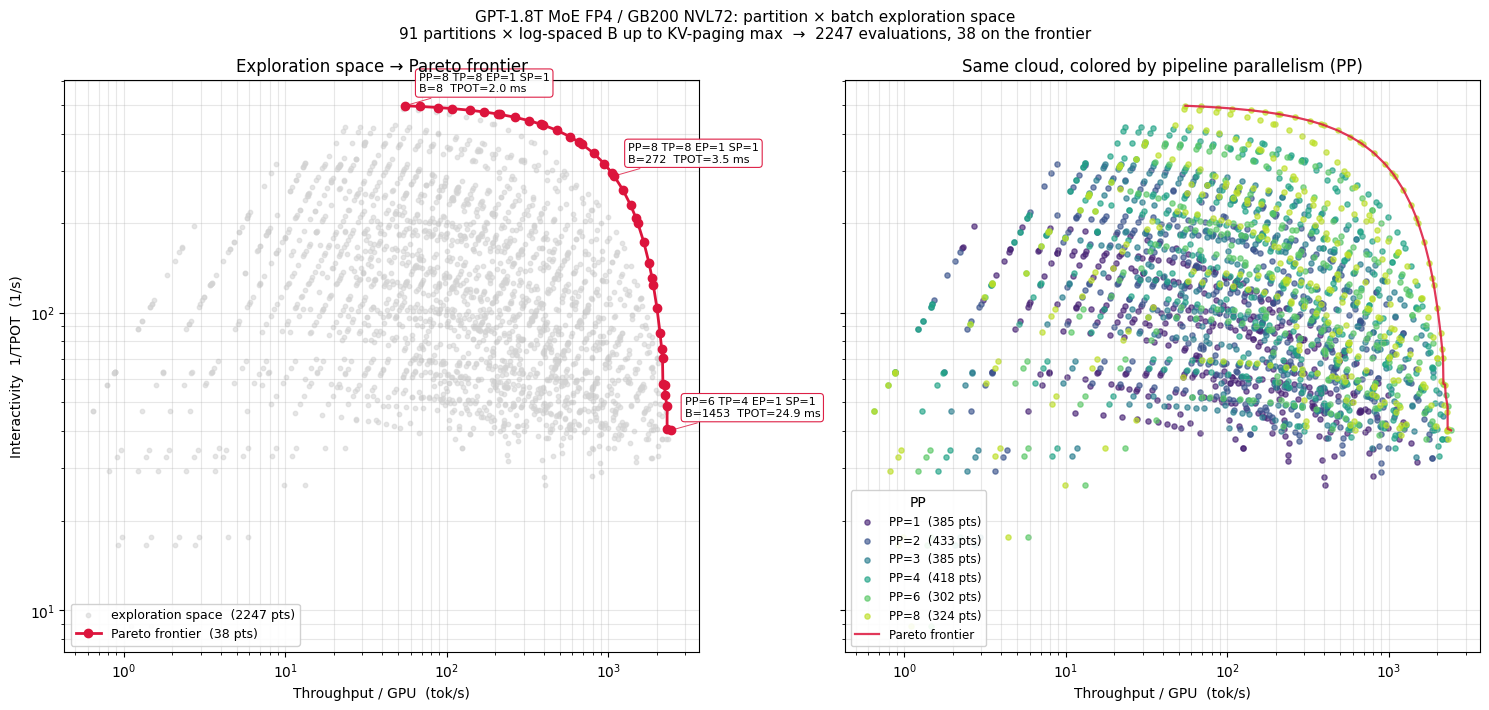

In [5]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 7.2), sharex=True, sharey=True)

xs_all = [p.tput_per_gpu for p in all_points]
ys_all = [p.interactivity for p in all_points]
xs_fr = [p.tput_per_gpu for p in frontier]
ys_fr = [p.interactivity for p in frontier]

# --- Left panel: cloud + frontier ---
axL.scatter(xs_all, ys_all, s=10, color="lightgray", alpha=0.55,
            label=f"exploration space  ({len(all_points)} pts)")
axL.plot(xs_fr, ys_fr, "-o", color="crimson", lw=2.0, ms=6,
         label=f"Pareto frontier  ({len(frontier)} pts)")

# Annotate a handful of frontier corners (evenly spaced along the frontier).
if len(frontier) >= 3:
    idxs = [0, len(frontier) // 2, len(frontier) - 1]
else:
    idxs = list(range(len(frontier)))
for i in idxs:
    p = frontier[i]
    axL.annotate(
        f"{p.part_label}\nB={p.B}  TPOT={p.TPOT_ms:.1f} ms",
        xy=(p.tput_per_gpu, p.interactivity),
        xytext=(10, 10), textcoords="offset points",
        fontsize=8, ha="left", color="black",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="crimson", alpha=0.95, lw=0.8),
        arrowprops=dict(arrowstyle="-", color="crimson", lw=0.7, alpha=0.8),
    )

axL.set_xscale("log")
axL.set_yscale("log")
axL.set_xlabel("Throughput / GPU  (tok/s)")
axL.set_ylabel("Interactivity  1/TPOT  (1/s)")
axL.set_title("Exploration space → Pareto frontier")
axL.grid(True, which="both", alpha=0.3)
axL.legend(loc="lower left", fontsize=9, framealpha=0.9)

# --- Right panel: colored by PP ---
pps_sorted = sorted({p.partition.PP for p in all_points})
cmap = plt.get_cmap("viridis")
pp_colors = {pp: cmap(0.1 + 0.8 * i / max(1, len(pps_sorted) - 1))
             for i, pp in enumerate(pps_sorted)}

for pp in pps_sorted:
    sub = [p for p in all_points if p.partition.PP == pp]
    axR.scatter([p.tput_per_gpu for p in sub],
                [p.interactivity for p in sub],
                s=14, color=pp_colors[pp], alpha=0.65,
                label=f"PP={pp}  ({len(sub)} pts)")
axR.plot(xs_fr, ys_fr, "-", color="crimson", lw=1.6, alpha=0.85,
         label="Pareto frontier")

axR.set_xlabel("Throughput / GPU  (tok/s)")
axR.set_title("Same cloud, colored by pipeline parallelism (PP)")
axR.grid(True, which="both", alpha=0.3)
axR.legend(loc="lower left", fontsize=8.5, framealpha=0.9, title="PP")

fig.suptitle(
    f"GPT-1.8T MoE FP4 / GB200 NVL72: partition × batch exploration space\n"
    f"{len(partitions)} partitions × log-spaced B up to KV-paging max  →  "
    f"{len(all_points)} evaluations, {len(frontier)} on the frontier",
    fontsize=11,
)
fig.tight_layout()
plt.show()

## 6. Takeaways

- **The frontier is a small slice of the space.** Only a handful of the hundreds of `(partition, B)` evaluations sit on the envelope — most configurations are strictly dominated in both throughput/GPU and interactivity.
- **PP dominates regime selection.** Coloring by PP on the right panel makes the segmentation obvious: shallow PP lives in the high-interactivity corner (low per-GPU throughput, small B), deep PP in the high-throughput corner (large B amortizes warmup, more weights hidden behind traffic).
- **Within a partition, B traces a curve.** Fixing `(PP, TP, EP, SP)` and sweeping B gives a monotone arc — tput/GPU rises with B (weight reads amortize), interactivity falls (longer token time). Partitions differ in *where* those arcs sit, and the frontier picks the outer hull.
- **Why it matters for the other notebooks.** `pareto_vs_io`, `pareto_vs_mem`, and `pareto_vs_overhead` each re-run this exact enumeration once per hardware/overhead anchor, then plot only the frontier per anchor. The shifts between frontiers in those studies are shifts of this cloud — individual points moving in (tput, 1/TPOT) as the hardware changes.
- **What to swap.** Change `MODEL`/`SYSTEM`/`TUNER` in §1 to study a different model/system pair. Partition divisibility constraints in `PP_CHOICES` / `TP_CHOICES` / `EP_CHOICES` (§2) need to match the new model's `L`, `n_kv`, `H`, `n_experts`.